In [1]:
import sys
path = "../../.."
if path not in sys.path:
    sys.path.insert(0, path)

In [2]:
from data_retrieval import lipade_groundtruth
from absolute_path import absolutePath
from PIL import Image
import numpy as np
from torchvision import transforms
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import cosine_similarity
import clustering.evaluators as evaluators

root = "" # os.environ['DSDIR'] + '/HuggingFace_Models/'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = "cpu"

corpus = "lipade_groundtruth"
#distancePath = "../results/distance/" + corpus + "/"
#rawPath = "../results/raw/" + corpus + "/"
distancePath = f"/home/renard/HighVision_moi/representation/multimodal/results/distance/{corpus}/"
rawPath = f"/home/renard/HighVision_moi/representation/multimodal/results/raw/{corpus}/"

weightsPath = "../results/weights/" + corpus + "/"
batch_size = 32


x, _, y = lipade_groundtruth.getDataset(mode="similar")
x = [Image.open(p).convert("RGB") for p in x]


/home/renard/HighVision_moi/.venv2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SigLIP 2

In [ ]:
from transformers import AutoProcessor, AutoModel


model_save_path = "siglip2.pth"


# --- Modèle complet SigLIP2 (vision + texte)
model_name = "google/siglip2-base-patch16-224"
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.to(device)
model.eval()

representations = []

with torch.no_grad():
    for img in tqdm(x, desc="SigLIP2 image embeddings"):
        inputs = processor(images=img, return_tensors="pt").to(device)

        img_emb = model.get_image_features(**inputs)

        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)

        representations.append(img_emb.cpu().numpy()[0])

representations = np.vstack(representations)

sim = cosine_similarity(representations, representations)
distance = 1 - (sim + 1) / 2
np.fill_diagonal(distance, 0)

np.save(distancePath + f"siglip2_{model_name.replace('/', '_')}.npy", distance)
np.save(rawPath + f"siglip2_{model_name.replace('/', '_')}.npy", representations)

print("✔ SigLIP2 : embeddings et distances sauvegardés.")



SigLIP2 image embeddings: 100%|██████████| 279/279 [13:32<00:00,  2.91s/it]

✔ SigLIP2 : embeddings et distances sauvegardés.


Thresholds: 100%|██████████| 100/100 [00:01<00:00, 73.90it/s]


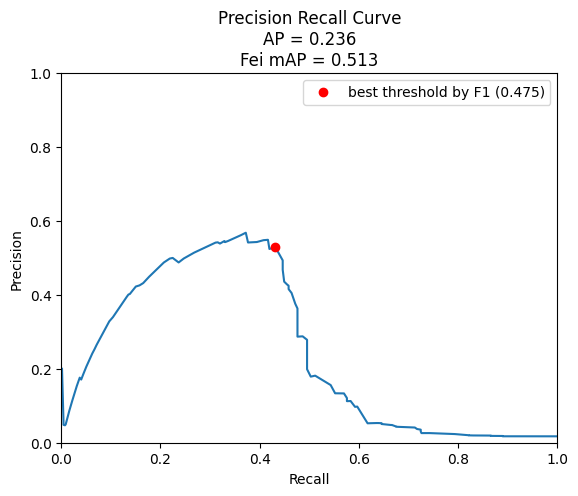

In [ ]:
name="test2"
method = f"siglip2_{name}"

thresholds_precision = 1000
thresholds = np.linspace(0, 1, thresholds_precision)

precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y)
f1 = np.max(f1s)
ArithmeticErrorP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y)
fei = evaluators.fei_mAP(y, distance)
sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)

# SigLIP 1

In [ ]:

from transformers import SiglipProcessor, SiglipModel


# SIGLIP 1 (vision + texte)

model_name = "google/siglip-base-patch16-224"

processor = SiglipProcessor.from_pretrained(model_name)
model = SiglipModel.from_pretrained(model_name)
model.to(device)
model.eval()


representations = []

with torch.no_grad():
    for img in tqdm(x, desc=f"SigLIP1 : {model_name}"):
        inputs = processor(images=img, return_tensors="pt").to(device)

        img_emb = model.get_image_features(**inputs) 

        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)

        representations.append(img_emb.cpu().numpy()[0])

representations = np.vstack(representations)

sim = cosine_similarity(representations, representations)
distance = 1 - (sim + 1) / 2
np.fill_diagonal(distance, 0)


np.save(distancePath + f"siglip1_{model_name.replace('/', '_')}.npy", distance)
np.save(rawPath + f"siglip1_{model_name.replace('/', '_')}.npy", representations)

print("✔ SigLIP 1 : embeddings et distances sauvegardés.")


/home/renard/HighVision_moi/.venv2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
SigLIP1 : google/siglip-base-patch16-224: 100%|██████████| 279/279 [23:36<00:00,  5.08s/it]

✔ SigLIP 1 : embeddings et distances sauvegardés.


Thresholds: 100%|██████████| 100/100 [00:01<00:00, 70.65it/s]


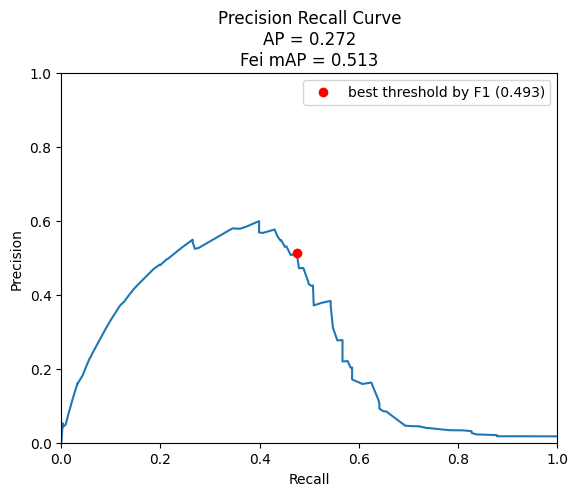

In [ ]:
name="test1"
method = f"siglip_{name}"

thresholds_precision = 1000
thresholds = np.linspace(0, 1, thresholds_precision)

precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y)
f1 = np.max(f1s)
ArithmeticErrorP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y)
fei = evaluators.fei_mAP(y, distance)
sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)

# Autres

In [ ]:
import clip
import open_clip
from transformers import AutoProcessor, AutoModel, SiglipProcessor, SiglipModel



# MODEL DEFINITIONS
# Each model is defined by a loader function + an extractor


def load_clip(model_name):
    model, preprocess = clip.load(model_name, device=device)
    return model, preprocess

def extract_clip(model, preprocess, img):
    img_t = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        f = model.encode_image(img_t)
        f = f / f.norm(dim=-1, keepdim=True)
    return f.cpu().numpy()[0]


def load_siglip(model_name):
    processor = SiglipProcessor.from_pretrained(model_name)
    model = SiglipModel.from_pretrained(model_name).to(device).eval()
    return model, processor

def extract_siglip(model, processor, img):
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        f = model.get_image_features(**inputs)
        f = f / f.norm(dim=-1, keepdim=True)
    return f.cpu().numpy()[0]


def load_siglip2(model_name):
    processor = AutoProcessor.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()
    return model, processor

def extract_siglip2(model, processor, img):
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        f = model.get_image_features(**inputs)
        f = f / f.norm(dim=-1, keepdim=True)
    return f.cpu().numpy()[0]


def load_openclip(model_name, pretrained):
    model, preprocess = open_clip.create_model_and_transforms(
        model_name, pretrained=pretrained
    )
    model = model.to(device).eval()
    return model, preprocess

def extract_openclip(model, preprocess, img):
    img_t = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        f = model.encode_image(img_t)
        f = f / f.norm(dim=-1, keepdim=True)
    return f.cpu().numpy()[0]


def load_hf_vision(model_name):
    processor = AutoProcessor.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()
    return model, processor

def extract_hf_vision(model, processor, img):
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**inputs)

    # BEiT / DINOv2 / MAE / IJEPA → pooler_output ou mean pool
    if hasattr(out, "pooler_output"):
        f = out.pooler_output
    else:
        f = out.last_hidden_state.mean(dim=1)

    f = f / f.norm(dim=-1, keepdim=True)
    return f.cpu().numpy()[0]


In [ ]:
# LIST OF MODELS TO TEST

MODELS = {
    # --- CLIP ---
    "clip_vitl14": {
        "loader": lambda: load_clip("ViT-L/14"),
        "extract": extract_clip
    },

    # --- SigLIP 1 ---
    "siglip_base": {
        "loader": lambda: load_siglip("google/siglip-base-patch16-224"),
        "extract": extract_siglip
    },

    # --- SigLIP 2 ---
    "siglip2_base": {
        "loader": lambda: load_siglip2("google/siglip2-base-patch16-224"),
        "extract": extract_siglip2
    },

    # --- DINOv2 ---
    "dinov2_large": {
        "loader": lambda: load_hf_vision("facebook/dinov2-large"),
        "extract": extract_hf_vision
    },

    # --- EVA CLIP / OpenCLIP ---
    "eva_clip_h14": {
        "loader": lambda: load_openclip("ViT-H-14", "laion2b_s32b_b79k"),
        "extract": extract_openclip
    },

    # --- ALIGN ---
    "align_base": {
        "loader": lambda: load_hf_vision("kakaobrain/align-base"),
        "extract": extract_hf_vision
    },

    # --- BEiT ---
    "beit_base": {
        "loader": lambda: load_hf_vision("microsoft/beit-base-patch16-224"),
        "extract": extract_hf_vision
    },

    # --- I-JEPA ---
    "ijepa_base": {
        "loader": lambda: load_hf_vision("facebook/ijepa-base"),
        "extract": extract_hf_vision
    },
}


problem eva, align, ijepa

In [ ]:
# RUN ALL MODELS


for model_name, cfg in MODELS.items():
    print(f"\n==================== {model_name} ====================")

    # Load
    model, processor = cfg["loader"]()

    # Extract embeddings
    reps = []
    for img in tqdm(x, desc=f"Extracting {model_name}"):
        reps.append(cfg["extract"](model, processor, img))

    reps = np.vstack(reps)

    # Similarity + distance
    sim = cosine_similarity(reps, reps)
    dist = 1 - (sim + 1) / 2
    np.fill_diagonal(dist, 0)

    # Save
    np.save(distancePath + f"{model_name}.npy", dist)
    np.save(rawPath + f"{model_name}.npy", reps)

    print(f"✔ Saved {model_name}")

print("\nAll models processed!")


Thresholds: 100%|██████████| 100/100 [00:01<00:00, 72.20it/s]


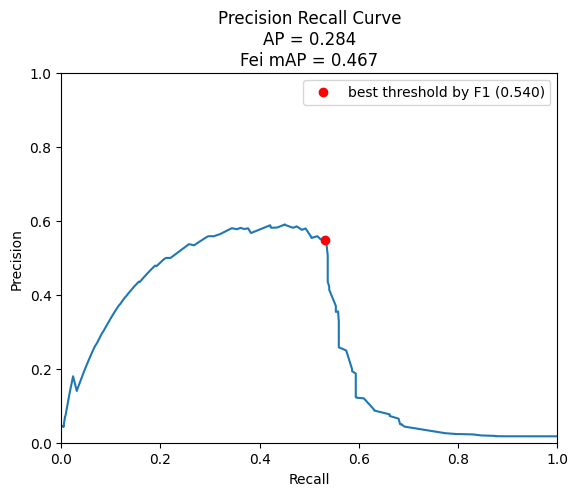

In [9]:
distance = np.load(distancePath + "clip_vitl14.npy")
name="test1"
method = f"clip_vitl14_{name}"

thresholds_precision = 1000
thresholds = np.linspace(0, 1, thresholds_precision)

precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y)
f1 = np.max(f1s)
ArithmeticErrorP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y)
fei = evaluators.fei_mAP(y, distance)
sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)

Thresholds: 100%|██████████| 100/100 [00:01<00:00, 77.32it/s]


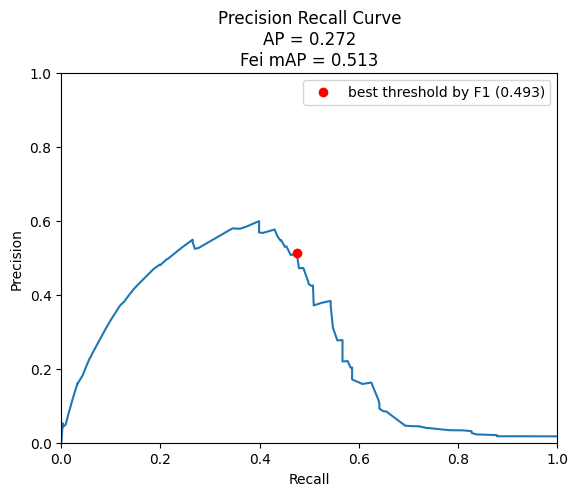

In [10]:
distance = np.load(distancePath + "siglip_base.npy")
name="test1"
method = f"siglip_base_{name}"

thresholds_precision = 1000
thresholds = np.linspace(0, 1, thresholds_precision)

precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y)
f1 = np.max(f1s)
ArithmeticErrorP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y)
fei = evaluators.fei_mAP(y, distance)
sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)

Thresholds: 100%|██████████| 100/100 [00:01<00:00, 81.84it/s]


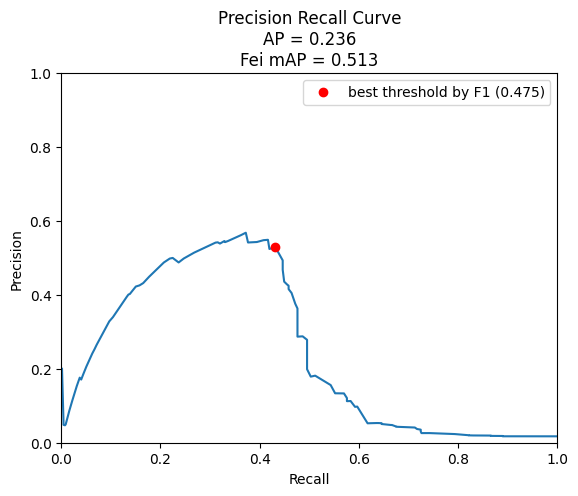

In [11]:
distance = np.load(distancePath + "siglip2_base.npy")
name="test1"
method = f"siglip2_base_{name}"

thresholds_precision = 1000
thresholds = np.linspace(0, 1, thresholds_precision)

precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y)
f1 = np.max(f1s)
ArithmeticErrorP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y)
fei = evaluators.fei_mAP(y, distance)
sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)

Thresholds: 100%|██████████| 100/100 [00:02<00:00, 45.95it/s]


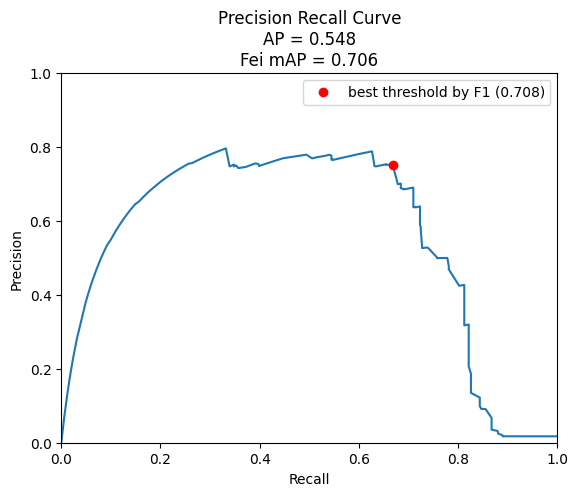

In [12]:
distance = np.load(distancePath + "dinov2_large.npy")
name="test1"
method = f"dinov2_large_{name}"

thresholds_precision = 1000
thresholds = np.linspace(0, 1, thresholds_precision)

precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y)
f1 = np.max(f1s)
ArithmeticErrorP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y)
fei = evaluators.fei_mAP(y, distance)
sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)

Thresholds: 100%|██████████| 100/100 [00:02<00:00, 41.20it/s]


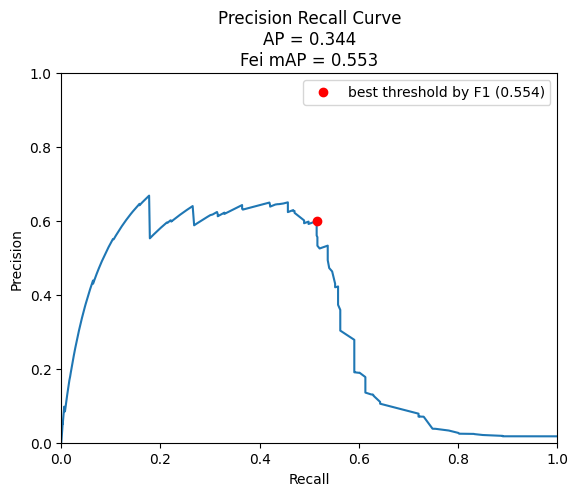

In [13]:
distance = np.load(distancePath + "beit_base.npy")
name="test1"
method = f"beit_base_{name}"

thresholds_precision = 1000
thresholds = np.linspace(0, 1, thresholds_precision)

precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y)
f1 = np.max(f1s)
ArithmeticErrorP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y)
fei = evaluators.fei_mAP(y, distance)
sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)